## Processing the results

First, we'll read in the data from the file and do some minimal cleanup. Load the necessary tools.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
#from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Now read in the data - including the spatial data involved with the creation of the simulation.

In [50]:
# set up the filenames!

rawDataDir = "/Users/swise/workspace/takamatsu/data/takamatsuTsunamiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/output/results/"

waterFloodedFile = rawDataDir + "flooded_reproj.shp"
roadsFile = rawDataDir + "roads_simple.shp"
shelterFile = rawDataDir + "sheltersWithParking.shp"
#stationsFile = rawDataDir + "trainStationsWithPassengers.shp"

# read in the list of files from the directory

workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder

roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
shelters = geopandas.read_file(shelterFile)
#stations = geopandas.read_file(stationsFile)

In [3]:
total_sim_time = 60

Let's create a helper function to extract the relevant information from the raw records!

In [28]:
# helper function
def extractEvacTime(s, totalSteps):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "FINISHED_PREP_START_EVACUATING" in record:
        startTime = record["FINISHED_PREP_START_EVACUATING"]
    elif "BEGIN_EVACUATING" in record:
        startTime = record["BEGIN_EVACUATING"]
    else:
        return -1
        
    finishTime = totalSteps

    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "ENTER_SHELTER" in record:
        finishTime = record["ENTER_SHELTER"]
    elif "DONE" in record:
        finishTime = record["DONE"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

def getAllValidEvacs(df, total_sim_time):
    raw = [extractEvacTime(s, total_sim_time) for s in df["evacuatingRecord"]]
    a = np.array(raw)
    return a[a >= 0]

Does it work? Let's try it on one example.

In [12]:
f = "out_params_default_txt_noVertEvac0.txt" # hard code it to be sure you get a proper example
#f_roads = "out_params_default_txt_vertEvac0_roaduse_5.txt"

raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
#raw_road_data = pd.DataFrame(pd.read_csv(workingDir + f_roads, sep='\t', header=None))

total_sim_time = 60

In [ ]:
raw_road_data = raw_road_data.rename(columns={0: "roads", 1: "usage"})

#raw_road_data.columns
raw_road_data["usage"] = [np.fromstring(x[1:-1], dtype=int, sep=', ') for x in raw_road_data["usage"]]

record_time_step = int(f_roads.split('_')[-1].replace(".txt", ""))

# how many steps were recorded - based on how frequently the roads were checked
total_sim_time = len(raw_road_data["usage"][0]) * record_time_step


In [29]:
evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
example = getAllValidEvacs(evacuees, total_sim_time)

In [30]:
evacuees["evacuatingRecord"].get(0)

'BEGIN_EVACUATING:0.0,EVAC_ORDER_PROMPTED_AT:0,MOVE_TO_HOME_FAILED_BUT_WILL_RETRY:1,ARRIVED_HOME_PREP_STARTED:2,FINISHED_PREP_START_EVACUATING:45,ENTER_SHELTER:60'

In [31]:
example

array([15., 13., 20., ...,  2.,  5., 12.])

In [ ]:
takeAllValues = pd.array([extractEvacTime(x, total_sim_time) for x in evacuees["evacuatingRecord"]])
shortEvacs = evacuees[takeAllValues < 15]
records = shortEvacs["evacuatingRecord"]

In [ ]:
print(f)
records.get(19)

In [ ]:
shortEvacs["evacuatingRecord"].get(shortEvacs.index[0])

In [ ]:
evacuees["evacuatingRecord"].get(evacuees.index[0])

In [ ]:
x = [extractEvacTime(x, total_sim_time) for x in evacuees["evacuatingRecord"]]
x

In [ ]:
evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
evacTime_evacuated = getAllValidEvacs(evacuees, total_sim_time)

still_evacuating = raw_data[raw_data["status"] == "Evacuating"].reset_index()
evacTime_evacuating = getAllValidEvacs(evacuees, total_sim_time)

#trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()


What does an evacuation record look like, just as an example?

In [41]:
evacuaters = raw_data[raw_data["evacuatingRecord"].notna()]
e = evacuaters["evacuatingRecord"]
e.get(e.index[0])

'BEGIN_EVACUATING:0.0,EVAC_ORDER_PROMPTED_AT:0,MOVE_TO_HOME_FAILED_BUT_WILL_RETRY:0,ARRIVED_HOME_PREP_STARTED:1,FINISHED_PREP_START_EVACUATING:46,SET_TO_INUNDATED:60,FLOOD_PROMPTED_AT:60'

In [ ]:
pd.unique(raw_data["flooded"])

In [56]:
pd.unique(raw_data.status)

array(['Home', 'Trapped', 'Evacuated', 'Evacuating', 'Sheltering'],
      dtype=object)

Ok, go through the files and pull out the evacuating times.

In [57]:
evacueeFullData = []
evacuatingFullData = []
trappedFullData = []
numTrapped = []
vertical = []
total_evacuating = []

# extract them
for f in files:
    
    print(f)
    
    if not (f.startswith("out_params_default") and f.endswith("txt")) or "trackedAgents" in f or "roaduse" in f or "heatmap" in f:
        continue

    vertical.append("_vertEvac" in f)
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file

    total_evacuating.append(raw_data[raw_data["evacuatingRecord"].notna()].shape[0])
    
    # successful evacuees
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evacueeFullData.append(getAllValidEvacs(evacuees, total_sim_time))
    
    # incomplete evacuations
    evacuees = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    evacuatingFullData.append(getAllValidEvacs(evacuees, total_sim_time))
    
    # trapped
    trapped = raw_data[raw_data["status"] == "Trapped"].reset_index()
    trappedFullData.append(trapped)
    numTrapped.append(len(trapped))
       
#len(evacueeFullData)
print(numTrapped)
if(len(evacueeFullData) == 0):
    print("Did you remember to update the filename prefix?")
else:
    len(evacueeFullData[0])

out_params_default_txt_noVertEvac20_trackedAgents_.txt
out_params_default_txt_vertEvac8_trackedAgents_.txt
out_params_default_txt_noVertEvac18.txt
out_params_default_txt_noVertEvac30.txt
out_params_default_txt_noVertEvac24.txt
out_params_default_txt_vertEvac17_roaduse_5.txt
out_params_default_txt_vertEvac5_trackedAgents_.txt
out_params_default_txt_noVertEvac25.txt
out_params_default_txt_noVertEvac31.txt
out_params_default_txt_noVertEvac19.txt
out_params_default_txt_vertEvac13_roaduse_5.txt
out_params_default_txt_noVertEvac30_trackedAgents_.txt
out_params_default_txt_noVertEvac22_roaduse_5.txt
out_params_default_txt_noVertEvac35_roaduse_5.txt
out_params_default_txt_vertEvac19_trackedAgents_.txt
out_params_default_txt_vertEvac14_trackedAgents_.txt
out_params_default_txt_noVertEvac27.txt
out_params_default_txt_noVertEvac33.txt
out_params_default_txt_noVertEvac31_roaduse_5.txt
out_params_default_txt_noVertEvac10_trackedAgents_.txt
out_params_default_txt_noVertEvac32.txt
out_params_default_

In [83]:
vertical

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 True,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 True]

### Trapped

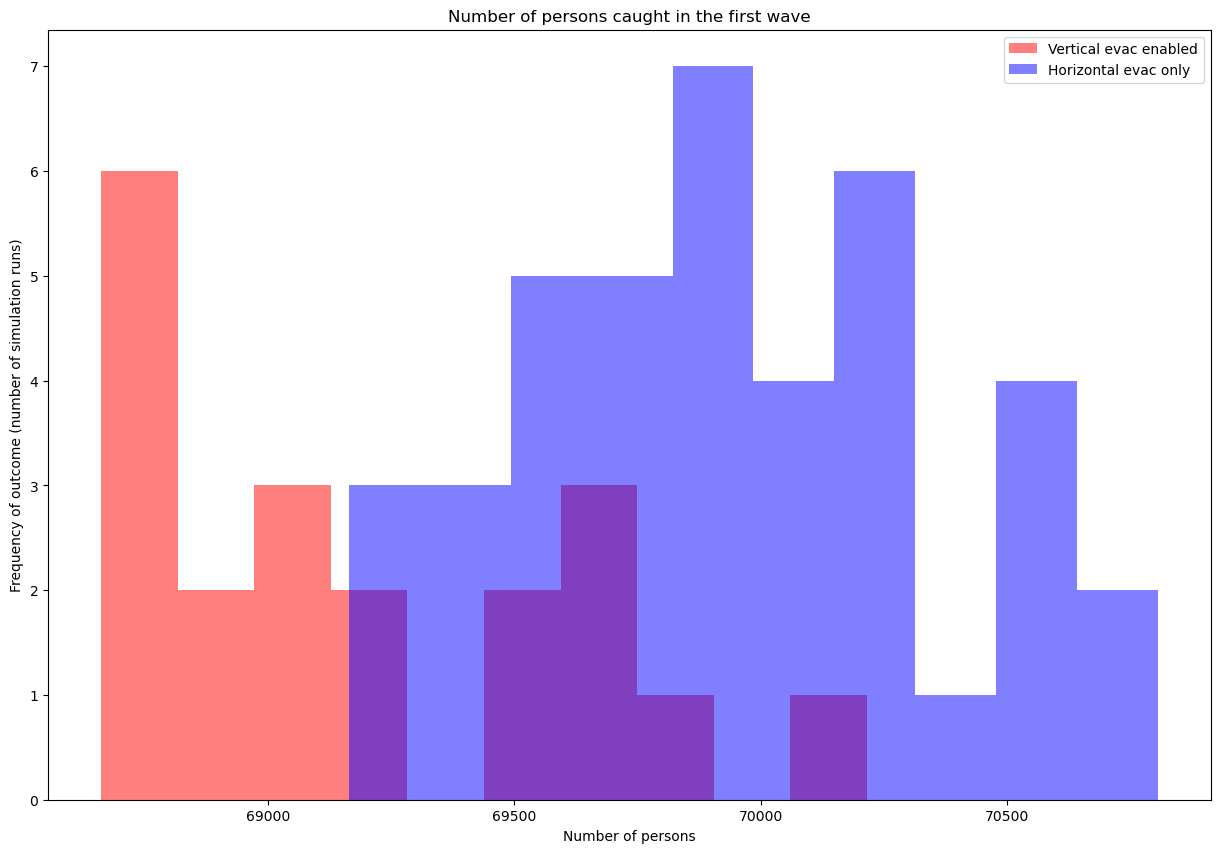

In [85]:
trappedCounts_vert = pd.Series(numTrapped)[vertical]
nonverts = [not x for x in vertical]
trappedCounts_nonVert = pd.Series(numTrapped)[nonverts]

fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
ax.hist(trappedCounts_vert, color='red', label="Vertical evac enabled", alpha=.5)
ax.hist(trappedCounts_nonVert, color='blue', label="Horizontal evac only", alpha=.5)
ax.legend()
ax.set_title("Number of persons caught in the first wave")
ax.set_xlabel("Number of persons")
ax.set_ylabel("Frequency of outcome (number of simulation runs)")

trappedFilename = "trappedDist.png"
plt.savefig(trappedFilename, format="png", dpi=720)


### Vertical Evacuation - Times

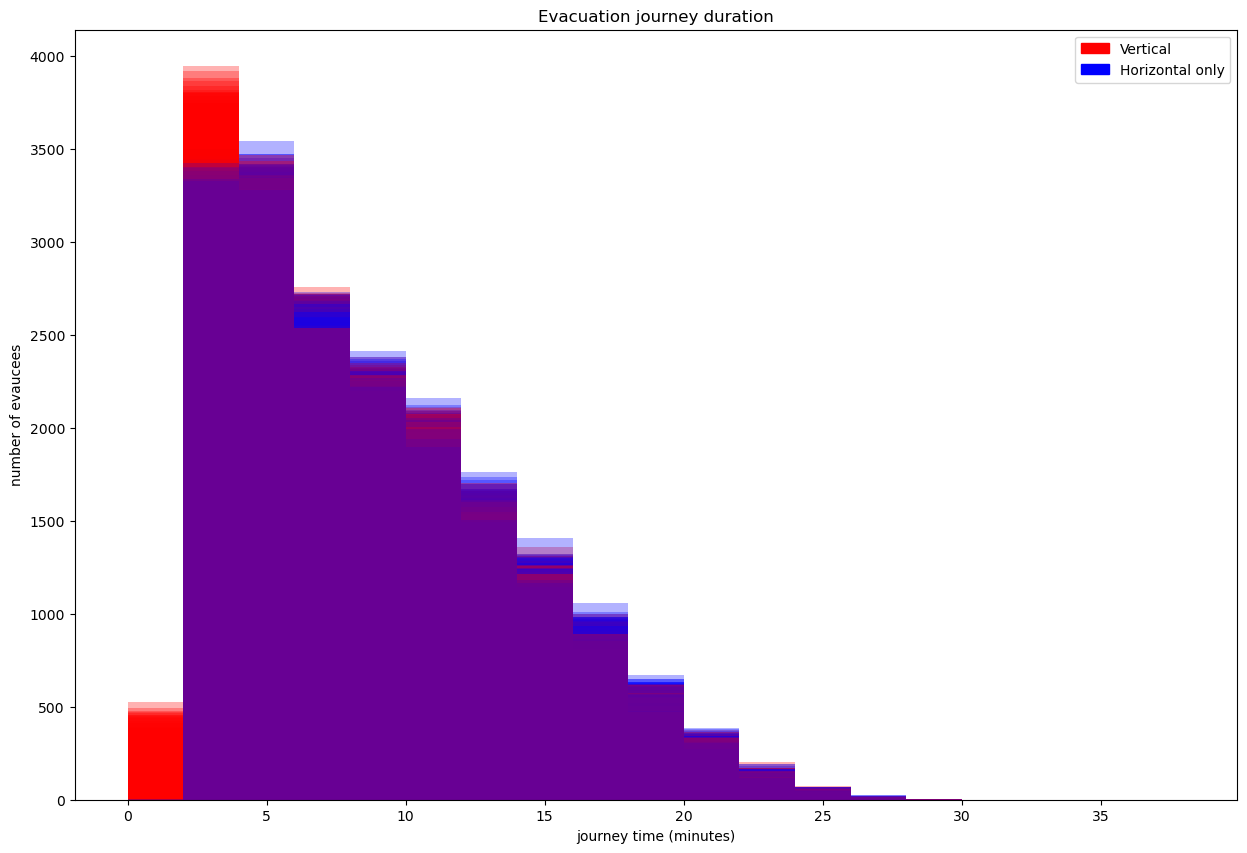

In [82]:
# pull out the noVert and vertEvac separately; make two plots and, for each instance, plot them on either side for journey times
#vertEvac = [not "_vertEvac" in f for f in files]
colors = ["red", "blue"]

# two graph version
fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
xbins = np.arange(0, 40, 2)
for index, val in enumerate(evacueeFullData):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0        
    ax.hist(val, bins=xbins, alpha=.3, color=colors[myAxis])

ax.set_title("Evacuation journey duration")
ax.set_xlabel("journey time (minutes)")
ax.set_ylabel("number of evaucees")

vert_patch = mpatches.Patch(color='red', label='Vertical')
horiz_patch = mpatches.Patch(color='blue', label='Horizontal only')

ax.legend(handles=[vert_patch, horiz_patch])

journeyDurationComparisonFilename = "journeyDurationComparison.png"
plt.savefig(journeyDurationComparisonFilename, format="png", dpi=720)

Text(0, 0.5, 'number of evaucees')

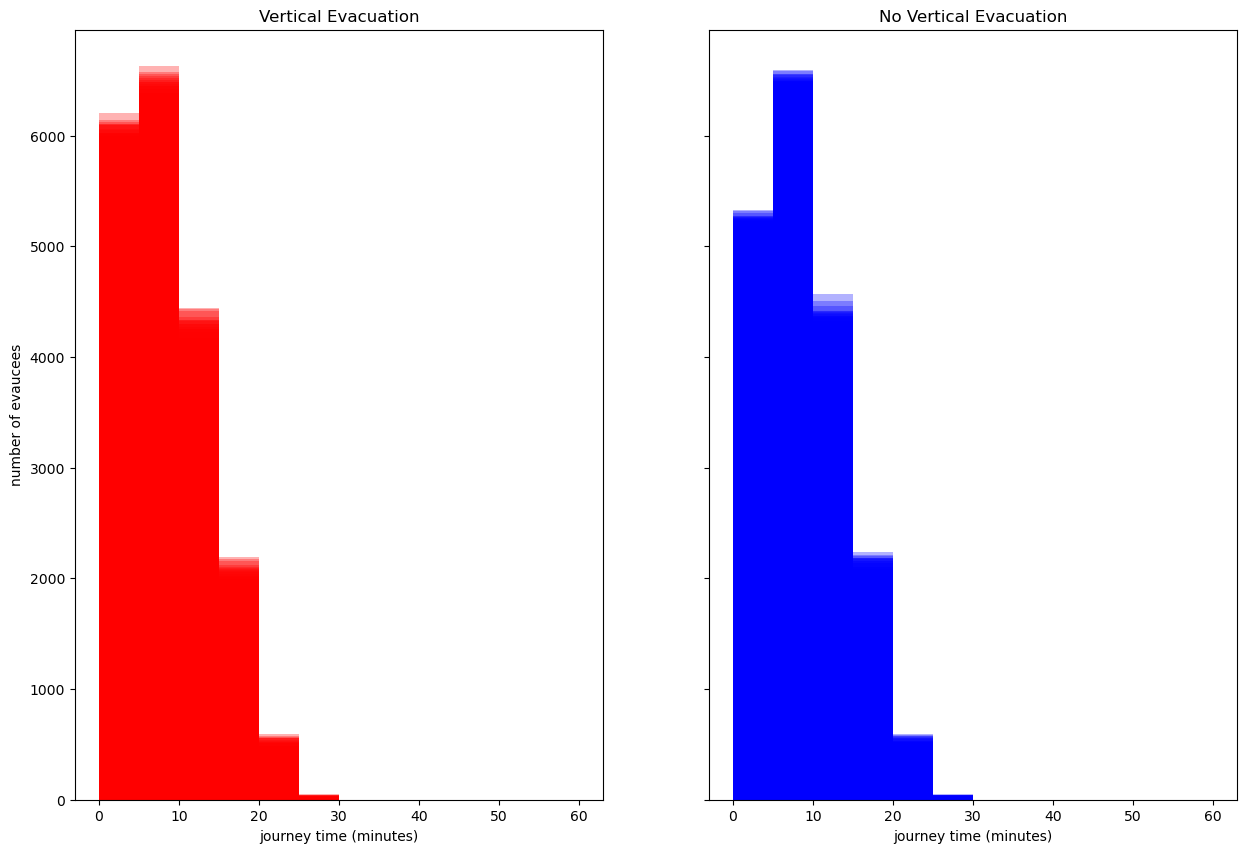

In [37]:
# pull out the noVert and vertEvac separately; make two plots and, for each instance, plot them on either side for journey times
#vertEvac = [not "_vertEvac" in f for f in files]
colors = ["red", "blue"]

# two graph version
fig, axs = plt.subplots(ncols=2, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
xbins = np.arange(0, 65, 5)
for index, val in enumerate(evacueeFullData):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0        
    axs[myAxis].hist(val, bins=xbins, alpha=.3, color=colors[myAxis])
    ax.hist(val, bins=xbins, alpha=.3, color=colors[myAxis])

axs[0].set_title("Vertical Evacuation")
axs[1].set_title("No Vertical Evacuation")
for ax in axs:
    ax.set_xlabel("journey time (minutes)")
axs[0].set_ylabel("number of evaucees")

### By Attribute

Make it possible to extract by attributes

In [38]:
def selectOnAttribute(df, targetValues, waterFile = None, exclude=False):
    
    myDf = df
    
    # select on the flooding scenario?
    if waterFile is not None:
        # pull out the runs on a specific water setting
        myDf = df[df["waterShapefile"] == waterFile]

    # make sure there's actually something to select!
    if len(targetValues) == 0:
        return myDf
        
    # iterate through, selecting on these
    for i, j in targetValues.items():
        
        if exclude:
            myDf = myDf[~myDf[i].isin(j)]
            
        else:
            myDf = myDf[myDf[i].isin(j)]            

    return myDf

In [42]:
df = evacuaters
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

# select on appropriate atts
# transform this into spatial data
gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(
    df[xcolname], df[ycolname]))
shelters_gdf = geopandas.GeoDataFrame(shelters, geometry=geopandas.points_from_xy(
    shelters["entranceX"], shelters["entranceY"]))

# aggregate by the final statuses
peopleInZone = gdf.groupby(['status'])#.agg({'ID': 'count'}).reset_index()

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)
#shelters = geopandas.read_file(shelters)

In [70]:
# precomputables
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

shelters_gdf = geopandas.GeoDataFrame(shelters, geometry=geopandas.points_from_xy(
    shelters["entranceX"], shelters["entranceY"]))

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)

# confirm CRS
layers = [roads, water, shelters_gdf]
for l in layers:
    l.set_crs(epsg=6690)

# gdfs
gdfs = []

for index, val in enumerate(trappedFullData):
    gdf = geopandas.GeoDataFrame(val, geometry=geopandas.points_from_xy(val[xcolname], val[ycolname]))
    gdf.set_crs(epsg=6690)
    gdfs.append(gdf)

<AxesSubplot:>

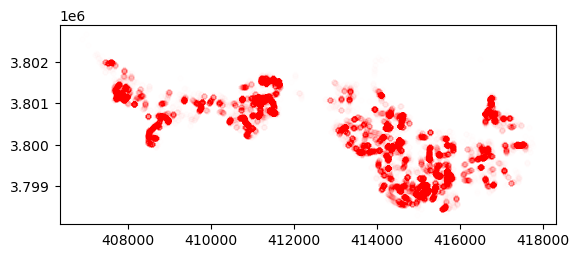

In [81]:
gdf.plot(color=colors[myAxis], zorder=3, marker='o', markersize=15, alpha=.003)

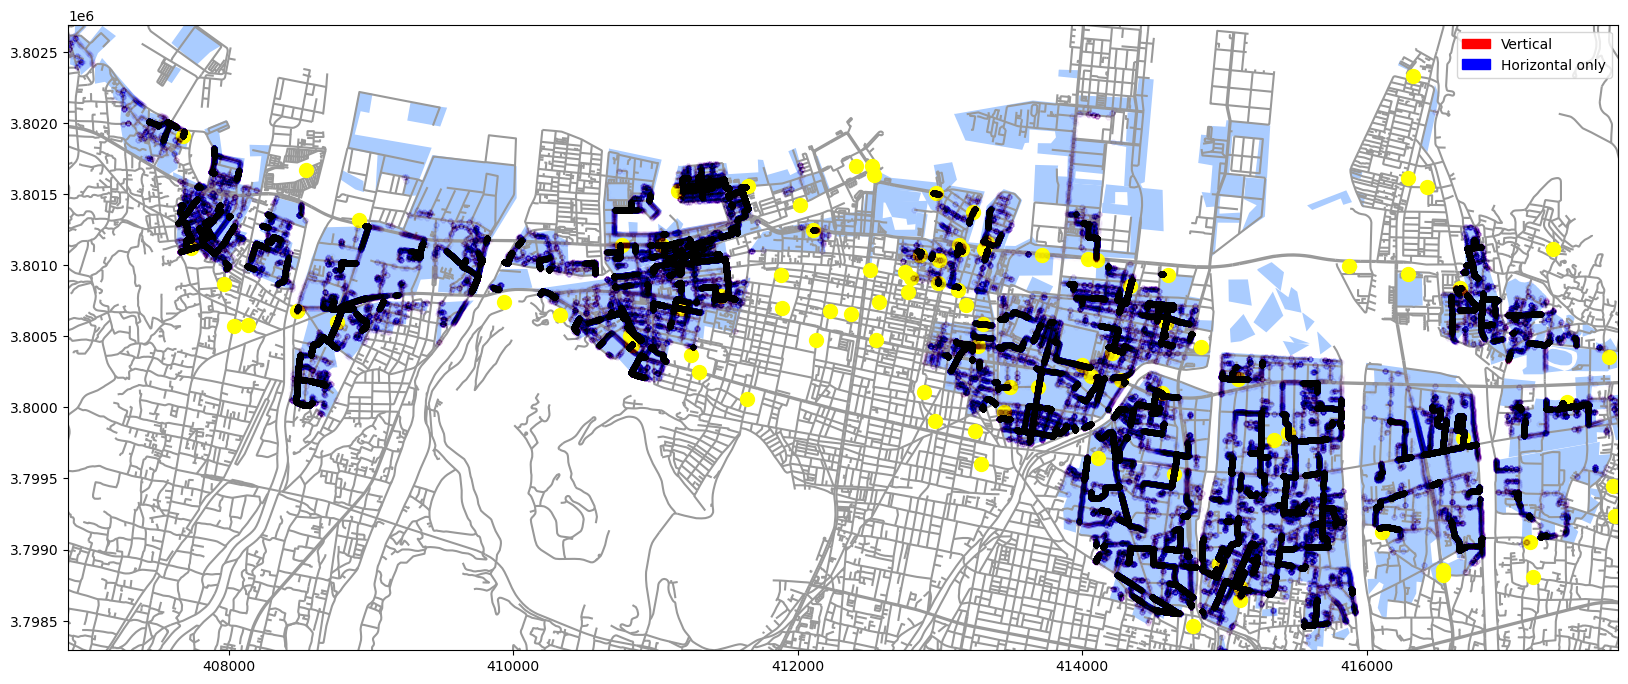

In [80]:
colors = ["red", "blue"]

# set up the figure
fig, base = plt.subplots(figsize=(20, 15))

# plot the background
roads.plot(ax=base, edgecolor='#999999')
water.plot(ax=base, color='#AACCFF')
shelters_gdf.plot(ax=base, zorder=2, markersize=100, color="yellow")

for index, gdf in enumerate(gdfs):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0
    gdf.plot(ax=base, color=colors[myAxis], zorder=3, marker='o', markersize=15, alpha=.005)
    
xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)

vert_patch = mpatches.Patch(color='red', label='Vertical')
horiz_patch = mpatches.Patch(color='blue', label='Horizontal only')

base.legend(handles=[vert_patch, horiz_patch])

finalTrappedLocsFilename = "finalTrappedLocations_both.png"
plt.savefig(finalTrappedLocsFilename, format="png", dpi=720)

In [68]:
len(trappedFullData)

60

(3797993.954, 3805450.646)

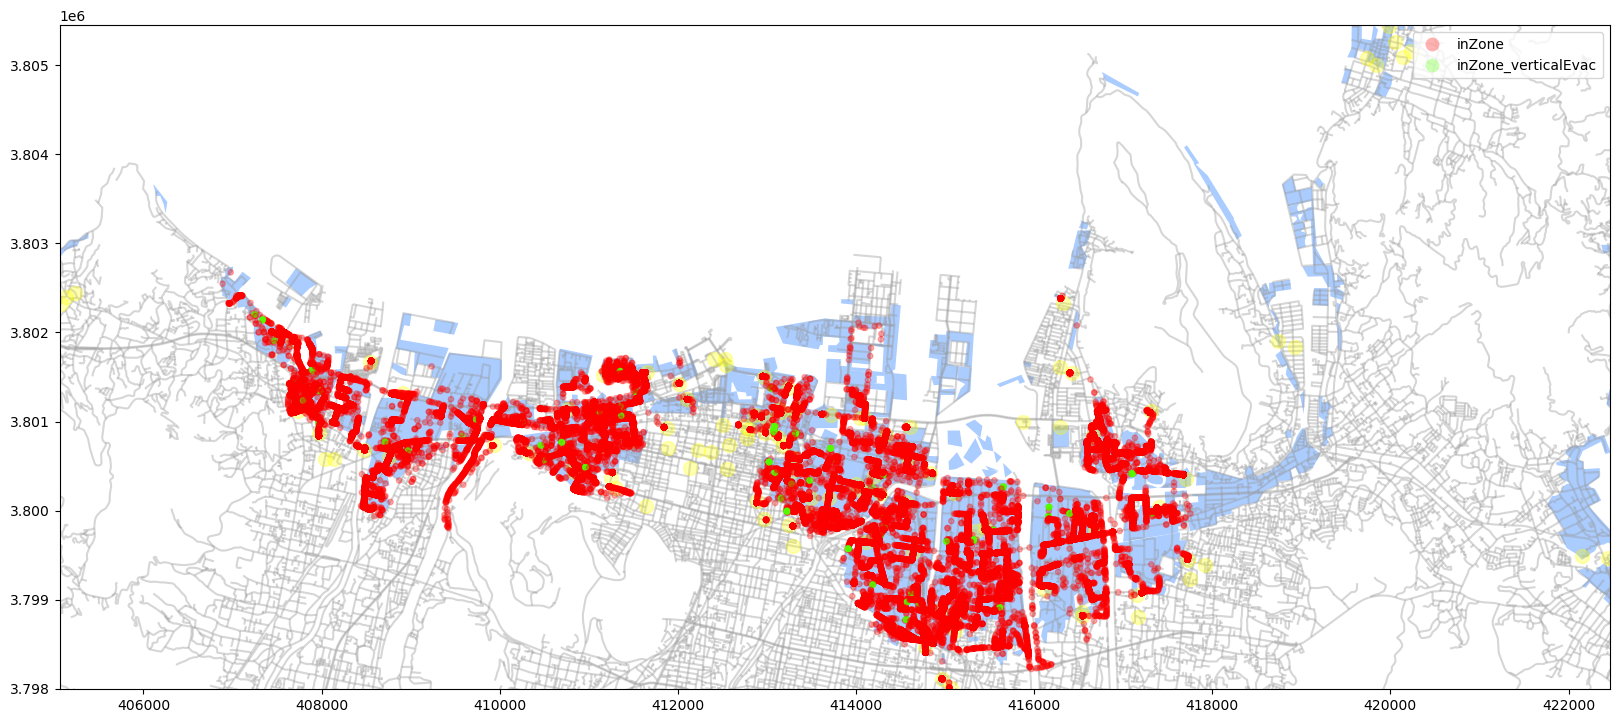

In [43]:
# plot the background and the people

layers = [roads, water, shelters_gdf, gdf]
for l in layers:
    l.set_crs(epsg=6690)

fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4)
water.plot(ax=base, color='#AACCFF')
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, column="flooded", cmap="prism", legend=True, zorder=3, marker='o', markersize=15, alpha=.3)

xmin, ymin, xmax, ymax = shelters_gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


In [ ]:
evacuaters

In [ ]:
from geopandas import GeoSeries
from shapely.geometry import LineString
from matplotlib.colors import TwoSlopeNorm

# plot the journey information
feats = []
time = []
for g in gdf.itertuples():
    j = LineString([[g.x_home, g.y_home], [g.x_loc, g.y_loc]])
    feats.append(j)
    time.append(extractEvacTime(g.evacuatingRecord, total_sim_time))
journeys = geopandas.GeoDataFrame(geometry=GeoSeries(feats))

#time /= np.max(time)
journeys["evacTime"] = time


In [ ]:
layers = [roads, water, shelters_gdf, gdf, journeys]
for l in layers:
    l.set_crs(epsg=6690)

In [ ]:
hist, bins = np.histogram(journeys['evacTime'])

In [ ]:
[journeys["evacTime"] < 20]

In [ ]:
print(journeys.type)
print(gdf.type)

In [ ]:
gdf.iloc[-1]["evacuatingRecord"]

In [ ]:
vmin, vmax, vcenter = journeys.evacTime.min(), journeys.evacTime.max(), journeys.evacTime.mean()
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = 'plasma'
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

In [ ]:
fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4, zorder=-2)
water.plot(ax=base, color='#AACCFF', zorder=-3)
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, legend=True, zorder=3, marker='o', markersize=5, alpha=.05, color='black')##column="flooded", cmap='plasma', )
journeys.plot(ax=base, column="evacTime", zorder=1, linewidth=.5, cmap=cmap, norm=norm, legend=False, alpha=journeys["evacTime"]/vmax)
fig.colorbar(cbar)

xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


30 minutes milling around time!

1. journey duration histogram (successful)
2. final location of unsuccessful individuals (+ journey times?)
3. basic info: number of agents

In [ ]:
import random
import numpy as np
import math

def r_func(sigma):
    return sigma * math.sqrt(-2 * np.log(random.random()))


In [ ]:
fig, base = plt.subplots(figsize=(20, 15))
size = 1000
for sig in [1, 2, 4, 8, 10]:
    sample = [30 + r_func(sig) for i in range(size)]
    base.hist(sample, alpha = .3, label=sig)#, cumulative=1, density=True, histtype="step")

base.legend()

### Sheltering in place (badly)

In [ ]:
sns.set_style('white')

exportMapByScenario(holder, "hicss_stillEvacuating_flooded.png", "Unfinished Evacuation Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Evacuating']})

Customising label legends: [here](https://stackoverflow.com/questions/74143732/customize-legend-labels-in-geopandas)
MatPlotLib [histogram documentation](https://matplotlib.org/stable/gallery/statistics/histogram_normalization.html)

Changing the markersize?
` cities.plot(markersize=cities['values']) `

[Projection info](https://www.practicaldatascience.org/notebooks/gis/50_gis_crs_geopandas.html) and [working with spatial data](https://earthdatascience.org/courses/earth-analytics-python/spatial-data-vector-shapefiles/python-change-spatial-extent-of-map-matplotlib-geopandas/)
